# FGES — Runtime Scaling vs d

固定 n，扫描不同 d，拟合 log-time/log-d（幂律）和 log-time/d（指数）两种关系，
找到实践上的最大可行 d。

In [1]:
import os, sys, time, warnings
import concurrent.futures
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "calm_dataset.py").exists() and (p / "coordinate_descent").exists():
            return p
    raise RuntimeError(f"repo root not found from {start}")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from calm_dataset import CalmDataset
print(f"REPO_ROOT: {REPO_ROOT}")


REPO_ROOT: /home/yin/DAG


In [2]:
ALGO_NAME = "FGES"
TAG       = "fges"

import fges_compat as _tetrad_mod
_p = pd.DataFrame(np.eye(2), columns=["x0", "x1"])
_s = _tetrad_mod.TetradSearch(_p); _s.use_sem_bic(); _s.run_fges(); del _p, _s
print("FGES (Tetrad JVM): OK")


May 15, 2026 1:06:11 PM java.util.prefs.FileSystemPreferences$6 run


FGES (Tetrad JVM): OK


In [3]:
D_LIST      = [5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 500]
N_SAMPLES   = 1000
TRIALS      = 3
DEGREE      = 2.0
GRAPH_TYPE  = "ER"
SEED_BASE   = 42
TIMEOUT_SEC = 3600
os.makedirs(str(REPO_ROOT / "experiments" / "results"), exist_ok=True)


In [4]:
def run_with_timeout(fn, timeout):
    """Returns (elapsed_sec, error_str_or_None)."""
    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as ex:
        fut = ex.submit(fn)
        t0 = time.perf_counter()
        try:
            fut.result(timeout=timeout)
            return time.perf_counter() - t0, None
        except concurrent.futures.TimeoutError:
            return float(timeout), "TIMEOUT"
        except Exception as e:
            return time.perf_counter() - t0, str(e)


def make_data(d, seed):
    ds = CalmDataset(
        n=N_SAMPLES, d=d, graph_type=GRAPH_TYPE,
        degree=DEGREE, sem_type="gauss",
        noise_ratio=4.0, seed=int(seed),
    )
    return ds.X


In [5]:
def run_algo(X: np.ndarray):
    cols = [f"x{i}" for i in range(X.shape[1])]
    df_X = pd.DataFrame(X, columns=cols).astype("float64")
    search = _tetrad_mod.TetradSearch(df_X)
    search.set_verbose(False)
    search.use_sem_bic(penalty_discount=2)
    search.run_fges()


## 主循环

In [6]:
records = []
stopped_at_d = None
rng = np.random.default_rng(SEED_BASE)
seeds = rng.integers(0, 10**9, size=(len(D_LIST), TRIALS))

for di, d in enumerate(D_LIST):
    if stopped_at_d is not None:
        break
    trial_times = []
    for t in range(TRIALS):
        X = make_data(d, int(seeds[di, t]))
        elapsed, err = run_with_timeout(lambda X=X: run_algo(X), TIMEOUT_SEC)
        if err == "TIMEOUT":
            print(f"d={d:4d}  trial={t+1}  TIMEOUT (>{TIMEOUT_SEC}s)")
            stopped_at_d = d
            break
        elif err:
            print(f"d={d:4d}  trial={t+1}  ERROR: {err}")
        else:
            trial_times.append(elapsed)
            print(f"d={d:4d}  trial={t+1}  {elapsed:.3f}s")
    if trial_times:
        records.append({"d": d, "mean_sec": np.mean(trial_times),
                        "std_sec": np.std(trial_times), "n_trials": len(trial_times)})

df = pd.DataFrame(records)
print()
print(df.to_string(index=False))


d=   5  trial=1  0.086s
d=   5  trial=2  0.063s
d=   5  trial=3  0.050s


d=  10  trial=1  0.296s
d=  10  trial=2  0.173s


d=  10  trial=3  0.144s


d=  20  trial=1  0.442s


d=  20  trial=2  0.278s


...

Num edges (backwards) = 1000


Num edges added: 1000


d= 500  trial=2  94.681s


Num edges added: 1000


d= 500  trial=3  108.986s

  d   mean_sec   std_sec  n_trials
  5   0.066128  0.014717         3
 10   0.204462  0.066024         3
 20   0.392324  0.081105         3
 30   0.984069  0.213418         3
 50   1.371024  0.668580         3
 75   3.370661  0.793552         3
100   5.913529  0.424099         3
150  10.888136  0.776049         3
200  16.078777  1.528562         3
300  33.815636  1.026614         3
500 107.576245 10.003334         3


## 可视化

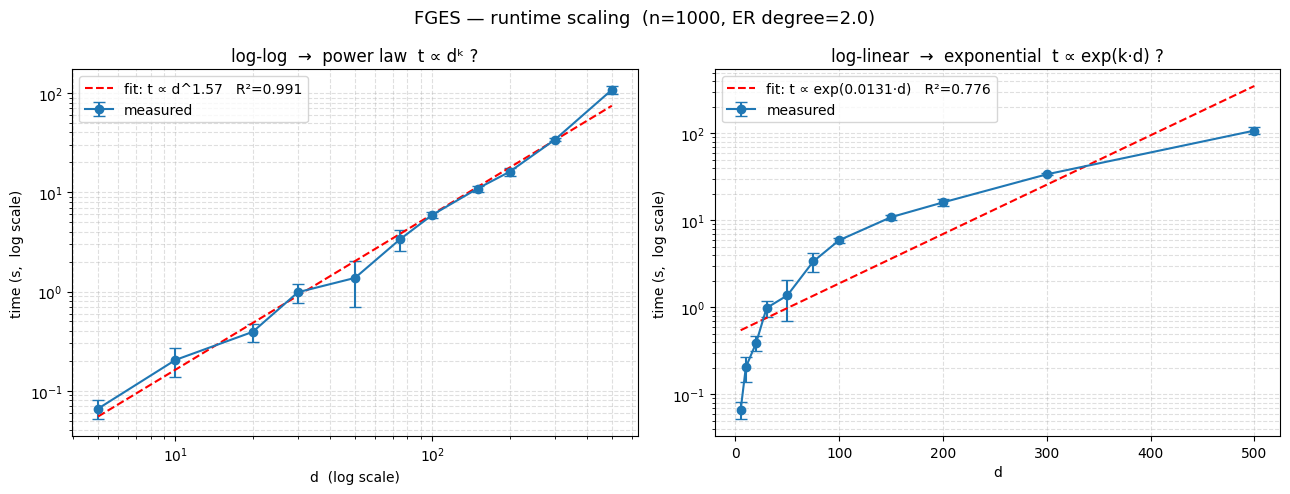

figure saved → /home/yin/DAG/experiments/results/fges_scaling.png


In [7]:
if df.empty or len(df) < 3:
    print("Not enough data points to plot.")
else:
    d_arr = df["d"].values.astype(float)
    t_arr = df["mean_sec"].values
    s_arr = df["std_sec"].values

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{ALGO_NAME} — runtime scaling  (n={N_SAMPLES}, ER degree={DEGREE})", fontsize=13)

    # ── log-log: power law ───────────────────────────────────────────────────
    ax = axes[0]
    ax.errorbar(d_arr, t_arr, yerr=s_arr, fmt="o-", capsize=4, label="measured")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("d  (log scale)"); ax.set_ylabel("time (s,  log scale)")
    ax.set_title("log-log  →  power law  t ∝ dᵏ ?")
    ax.grid(True, which="both", ls="--", alpha=0.4)
    sl, ic, r, *_ = stats.linregress(np.log(d_arr), np.log(t_arr))
    xf = np.logspace(np.log10(d_arr.min()), np.log10(d_arr.max()), 100)
    ax.plot(xf, np.exp(ic) * xf**sl, "r--",
            label=f"fit: t ∝ d^{sl:.2f}   R²={r**2:.3f}")
    ax.legend()

    # ── log-linear: exponential ──────────────────────────────────────────────
    ax = axes[1]
    ax.errorbar(d_arr, t_arr, yerr=s_arr, fmt="o-", capsize=4, label="measured")
    ax.set_yscale("log")
    ax.set_xlabel("d"); ax.set_ylabel("time (s,  log scale)")
    ax.set_title("log-linear  →  exponential  t ∝ exp(k·d) ?")
    ax.grid(True, which="both", ls="--", alpha=0.4)
    sl2, ic2, r2, *_ = stats.linregress(d_arr, np.log(t_arr))
    xf2 = np.linspace(d_arr.min(), d_arr.max(), 100)
    ax.plot(xf2, np.exp(ic2 + sl2 * xf2), "r--",
            label=f"fit: t ∝ exp({sl2:.4f}·d)   R²={r2**2:.3f}")
    ax.legend()

    plt.tight_layout()
    out_png = REPO_ROOT / "experiments" / "results" / f"{TAG}_scaling.png"
    plt.savefig(out_png, dpi=120)
    plt.show()
    print(f"figure saved → {out_png}")


## 结论

In [8]:
if len(df) >= 3:
    d_arr = df["d"].values.astype(float)
    t_arr = df["mean_sec"].values
    _, _, r_ll, *_ = stats.linregress(np.log(d_arr), np.log(t_arr))
    sl_ll, _, _, *_ = stats.linregress(np.log(d_arr), np.log(t_arr))
    sl_le, _, r_le, *_ = stats.linregress(d_arr, np.log(t_arr))
    # recompute properly
    sl_ll, ic_ll, r_ll, *_ = stats.linregress(np.log(d_arr), np.log(t_arr))
    sl_le, ic_le, r_le, *_ = stats.linregress(d_arr, np.log(t_arr))

    print("=== Scaling law summary ===")
    print(f"  log-log    R² = {r_ll**2:.4f}  →  t ∝ d^{sl_ll:.2f}  (power law / polynomial)")
    print(f"  log-linear R² = {r_le**2:.4f}  →  t ∝ exp({sl_le:.4f}·d)  (exponential)")
    if r_ll**2 > r_le**2:
        print(f"  Better fit: POWER LAW  (exponent ≈ {sl_ll:.2f})")
    else:
        print(f"  Better fit: EXPONENTIAL  (rate ≈ {sl_le:.4f} per node)")
    if stopped_at_d:
        print(f"  Practical max d  <  {stopped_at_d}  (timeout = {TIMEOUT_SEC}s, n = {N_SAMPLES})")
    else:
        print(f"  All d tested within timeout — practical max d ≥ {D_LIST[-1]}  (n = {N_SAMPLES})")
else:
    print("Not enough data for scaling analysis.")


=== Scaling law summary ===
  log-log    R² = 0.9913  →  t ∝ d^1.57  (power law / polynomial)
  log-linear R² = 0.7758  →  t ∝ exp(0.0131·d)  (exponential)
  Better fit: POWER LAW  (exponent ≈ 1.57)
  All d tested within timeout — practical max d ≥ 500  (n = 1000)
